<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_C/Exp3RegressionML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Regression

Regression is a **statistical technique in Machine Learning** used to **predict a continuous value**, such as:
- Predicting **house prices**
- Estimating **salary**
- Forecasting **temperature**

It tries to find the **relationship** between:
- **Input (Independent variable)** $\rightarrow$ $X$
- **Output (Dependent variable)** $\rightarrow$ $Y$

---

# 📈 Linear Regression

Linear Regression assumes that the relationship between $X$ and $Y$ is **linear**.

The **hypothesis function** is:

$$
h_\theta(x) = \theta_0 + \theta_1 x
$$

where:
- $\theta_0$ = intercept (bias term)
- $\theta_1$ = slope (weight)
- $x$ = input feature

🎯 **Goal:** Find the best $\theta_0$ and $\theta_1$ that fit the data (minimize the prediction error).

---

# 📊 What is Gradient?

- Gradient means the **slope** or **direction of the steepest increase** of a function.
- In optimization, gradient tells us **how much change in parameters** will change the error.

---

# ⚙️ What is Gradient Descent?

Gradient Descent is an **optimization algorithm** used to **minimize the cost function** by updating parameters step-by-step.

💡 **Idea:**
Start with random $\theta_0, \theta_1$, then move them **in the opposite direction of the gradient** to reduce error.

---

# 🧪 Step-by-Step Procedure

## 1️⃣ Initialize Parameters
Start with random values of $\theta_0$ and $\theta_1$.

## 2️⃣ Define the Cost Function (Error)

We use **Mean Squared Error (MSE)**:

$$
J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2
$$

where:
- $m$ = number of training samples
- $h_\theta(x^{(i)}) = \theta_0 + \theta_1 x^{(i)}$

## 3️⃣ Compute Gradients

The **partial derivatives** are:

$$
\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})
$$

$$
\frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}
$$

## 4️⃣ Update Parameters (Gradient Descent Rule)

$$
\theta_0 := \theta_0 - \alpha \cdot \frac{\partial J}{\partial \theta_0}
$$

$$
\theta_1 := \theta_1 - \alpha \cdot \frac{\partial J}{\partial \theta_1}
$$

where $\alpha$ = **learning rate**.

🔁 Repeat these updates **until convergence** (when the error stops decreasing).

---

# 🔢 Learning Rate ( $\alpha$ )

- Controls the **step size** of parameter updates.
- If $\alpha$ is **too large** $\rightarrow$ may **overshoot** the minimum.
- If $\alpha$ is **too small** $\rightarrow$ convergence will be **slow**.

✅ Choose $\alpha$ carefully!

---

# 💰 Cost Function – Why We Use It?

- Measures **how wrong** the model’s predictions are.
- Gradient Descent uses the **slope of the cost function** to adjust the parameters.
- Without it, the model would have **no feedback** to improve.

---

# ⬇️ How Gradient Descent Minimizes Error

At each step:
- Parameters move **opposite to the gradient** (downhill direction).
- This ensures $J(\theta)$ **decreases** with each iteration.
- Finally, parameters reach the **minimum point** (global minimum for Linear Regression).

---

# 🧩 Why Learning Rate & Cost Function Are Important

| Concept | Purpose |
|----------|----------|
| **Learning Rate ( $\alpha$ )** | Controls how big each step is in parameter updates |
| **Cost Function ( $J(\theta)$ )** | Measures model performance and guides optimization |

# Linear Regression using Gradient Descent and Scikit-Learn

## Objective
In this notebook, we will:
1. Implement **Linear Regression using Gradient Descent**.
2. Compare results with **Scikit-learn’s LinearRegression**.
3. Visualize:
   - Training and testing data with regression line
   - Cost function vs Iterations
   - Cost surface in 3D
4. Print and compare the learned values of **θ₀ (intercept)** and **θ₁ (slope)**.


## **Step 1: Import Libraries and Load Dataset**
We use:
- **pandas** for handling dataset
- **numpy** for matrix operations
- **matplotlib** for plotting
- **sklearn.model_selection.train_test_split** for splitting data
- **sklearn.linear_model.LinearRegression** for model comparison


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
df = pd.read_csv("Salary_Data.csv")
X = df['YearsExperience'].values.astype(float)
y = df['Salary'].values.astype(float)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


## **Step 2: Gradient Descent Implementation**
We normalize the data to improve convergence.  
We then run gradient descent to minimize the cost function.


In [ ]:
# Normalization (based on train only)
mu_train = X_train.mean()
sigma_train = X_train.std(ddof=0)
X_train_norm = (X_train - mu_train) / sigma_train
X_test_norm = (X_test - mu_train) / sigma_train

# Add bias column
X_train_design = np.column_stack((np.ones(len(X_train_norm)), X_train_norm))
X_test_design = np.column_stack((np.ones(len(X_test_norm)), X_test_norm))

# Gradient Descent Function
def gradient_descent(X, y, alpha, iterations, init_theta):
    theta = init_theta.copy()
    m = len(y)
    J_history = []
    for _ in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        gradient = (1/m) * X.T.dot(errors)
        theta -= alpha * gradient
        cost = (1/(2*m)) * np.sum(errors**2)
        J_history.append(cost)
    return theta, J_history

# Run Gradient Descent
initial_theta = np.array([8000.0, 20000.0])
alpha = 0.1
iterations = 350
theta_norm, J_history = gradient_descent(
    X_train_design, y_train, alpha, iterations, initial_theta
)

# Convert back to original scale
slope_gd = theta_norm[1] / sigma_train
intercept_gd = theta_norm[0] - (theta_norm[1] * mu_train / sigma_train)

print("Gradient Descent Results:")
print(f"Theta 0 (Intercept): {intercept_gd}")
print(f"Theta 1 (Slope): {slope_gd}")
print(f"Final Cost: {J_history[-1]}")


Gradient Descent Results:
Theta 0 (Intercept): 25918.43833489318
Theta 1 (Slope): 9339.08172381519
Final Cost: 14461107.806191826


## **Step 3: Predictions and Plots (Gradient Descent)**
We visualize:
1. Training data with regression line  
2. Training + Testing data with predictions  
3. Cost vs Iterations plot  
4. 3D Cost Surface visualization  


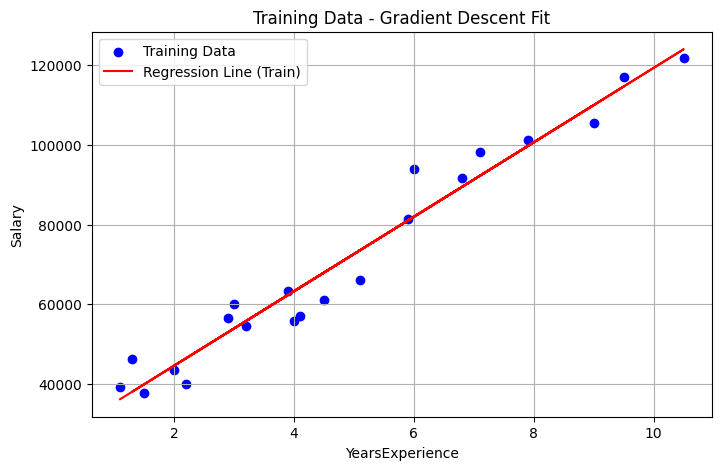

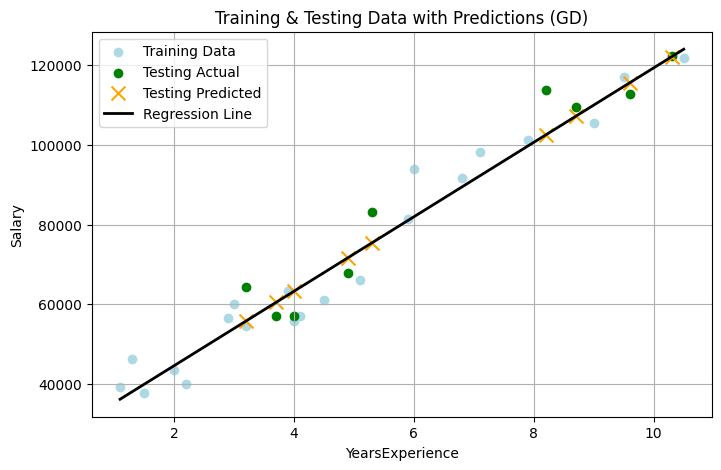

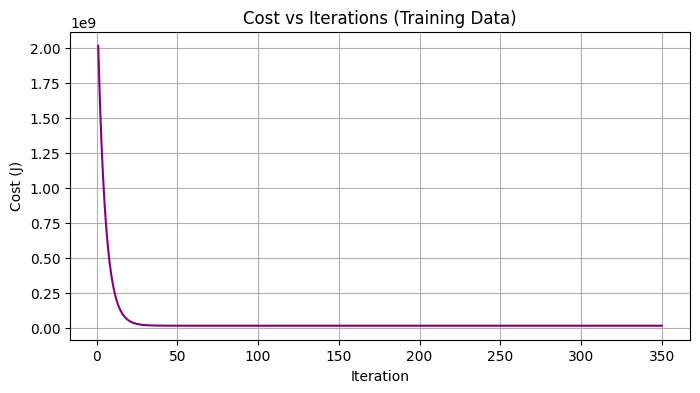

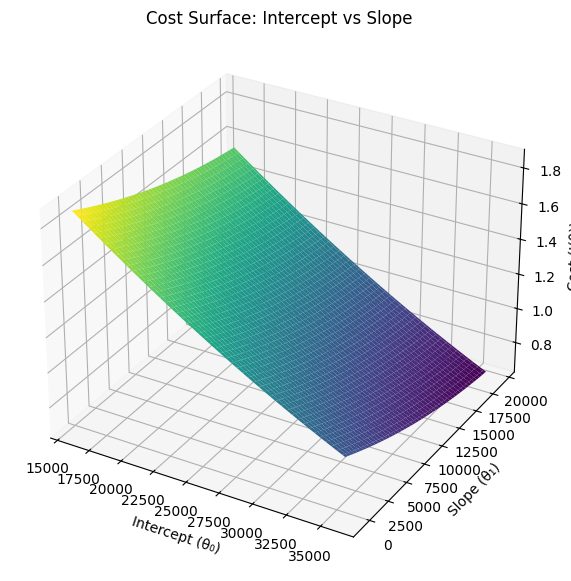

In [ ]:
# Predictions
y_pred_train = intercept_gd + slope_gd * X_train
y_pred_test = intercept_gd + slope_gd * X_test

# Convert arrays
X_train_np, y_train_np = np.array(X_train), np.array(y_train)
X_test_np, y_test_np = np.array(X_test), np.array(y_test)
y_pred_train_np, y_pred_test_np = np.array(y_pred_train), np.array(y_pred_test)

# 1️⃣ Training Data Plot
plt.figure(figsize=(8,5))
plt.scatter(X_train_np, y_train_np, color='blue', label='Training Data')
plt.plot(X_train_np, y_pred_train_np, color='red', label='Regression Line (Train)')
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Training Data - Gradient Descent Fit")
plt.legend()
plt.grid(True)
plt.show()

# 2️⃣ Training + Testing Data Plot
plt.figure(figsize=(8,5))
plt.scatter(X_train_np, y_train_np, color='lightblue', label='Training Data')
plt.scatter(X_test_np, y_test_np, color='green', label='Testing Actual')
plt.scatter(X_test_np, y_pred_test_np, color='orange', marker='x', s=100, label='Testing Predicted')

# Regression line
x_vals = np.linspace(min(X_train.min(), X_test.min()), max(X_train.max(), X_test.max()), 100)
y_vals = intercept_gd + slope_gd * x_vals
plt.plot(x_vals, y_vals, color="black", linewidth=2, label="Regression Line")

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Training & Testing Data with Predictions (GD)")
plt.legend()
plt.grid(True)
plt.show()

# 3️⃣ Cost vs Iterations
plt.figure(figsize=(8,4))
plt.plot(range(1, iterations+1), J_history, color='purple')
plt.xlabel("Iteration")
plt.ylabel("Cost (J)")
plt.title("Cost vs Iterations (Training Data)")
plt.grid(True)
plt.show()

# 4️⃣ 3D Cost Surface
theta_0_vals = np.linspace(intercept_gd - 10000, intercept_gd + 10000, 100)
theta_1_vals = np.linspace(slope_gd - 10000, slope_gd + 10000, 100)
theta_0_grid, theta_1_grid = np.meshgrid(theta_0_vals, theta_1_vals)

cost_vals = np.zeros_like(theta_0_grid)
for i in range(len(theta_0_vals)):
    for j in range(len(theta_1_vals)):
        theta_temp = np.array([theta_0_grid[i, j], theta_1_grid[i, j]])
        predictions = X_train_design.dot(theta_temp)
        errors = predictions - y_train
        cost_vals[i, j] = (1/(2 * len(y_train))) * np.sum(errors**2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(theta_0_grid, theta_1_grid, cost_vals, cmap='viridis')
ax.set_xlabel('Intercept (θ₀)')
ax.set_ylabel('Slope (θ₁)')
ax.set_zlabel('Cost (J(θ))')
ax.set_title('Cost Surface: Intercept vs Slope')
plt.show()


## **Step 4: Linear Regression using Scikit-Learn**
We now compare our results with Scikit-Learn’s `LinearRegression`, which uses the **Normal Equation** internally.


In [ ]:
# Reshape X for sklearn
X_train_reshaped = X_train.reshape(-1, 1)
X_test_reshaped = X_test.reshape(-1, 1)

# Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_reshaped, y_train)

# Get parameters
intercept_lr = lin_reg.intercept_
slope_lr = lin_reg.coef_[0]

print("Scikit-Learn Linear Regression Results:")
print(f"Theta 0 (Intercept): {intercept_lr}")
print(f"Theta 1 (Slope): {slope_lr}")


Scikit-Learn Linear Regression Results:
Theta 0 (Intercept): 25918.438334893202
Theta 1 (Slope): 9339.081723815198


## **Step 5: Plot Comparison**
We plot regression lines from both methods for comparison.


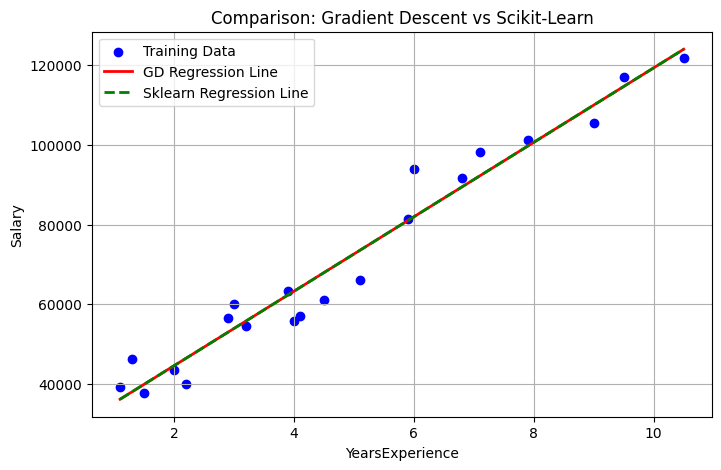

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_train_np, y_train_np, color='blue', label="Training Data")

# GD Regression line
plt.plot(x_vals, intercept_gd + slope_gd * x_vals, color='red', linewidth=2, label="GD Regression Line")

# Sklearn Regression line
plt.plot(x_vals, intercept_lr + slope_lr * x_vals, color='green', linestyle='--', linewidth=2, label="Sklearn Regression Line")

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Comparison: Gradient Descent vs Scikit-Learn")
plt.legend()
plt.grid(True)
plt.show()


## **Step 5: Plot Comparison Cost vs Iterations for Different Alpha Values**
We visualize how the cost function decreases across iterations

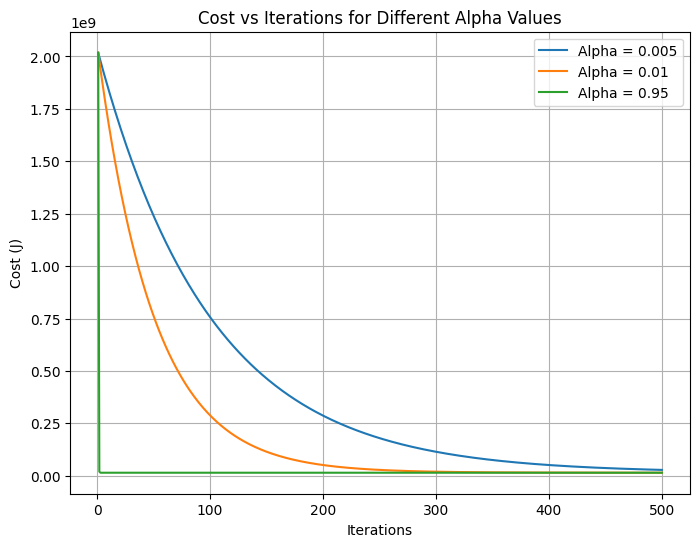


Results for alpha = 0.005:
Learned theta (normalized): [65913.62927587 25062.03916743]
Learned slope: 9174.498106234676
Learned intercept: 21570.2217624056
Final cost (train): 27925326.572840218

Results for alpha = 0.01:
Learned theta (normalized): [70643.01619397 25475.41926667]
Learned slope: 9325.824776514026
Learned intercept: 25568.196440815656
Final cost (train): 14549348.87982872

Results for alpha = 0.95:
Learned theta (normalized): [71057.33333333 25511.6333602 ]
Learned slope: 9339.081723815196
Learned intercept: 25918.438334893217
Final cost (train): 14461107.806191836


In [ ]:
# ------------------------------
# Initial theta values
# ------------------------------
initial_theta = np.array([8000.0, 20000.0])  # Example starting point
iterations = 500

# ------------------------------
# Test for different alpha values
# ------------------------------
alpha_values = [0.005, 0.01, 0.95]
theta_results = []
J_histories = []

for alpha in alpha_values:
    theta, J_history = gradient_descent(
        X_train_design, y_train, alpha, iterations, initial_theta
    )
    theta_results.append(theta)
    J_histories.append(J_history)

# ------------------------------
# Plot cost vs iterations for each alpha value
# ------------------------------
plt.figure(figsize=(8, 6))
for i, alpha in enumerate(alpha_values):
    plt.plot(range(1, iterations+1), J_histories[i], label=f'Alpha = {alpha}')

plt.xlabel('Iterations')
plt.ylabel('Cost (J)')
plt.title('Cost vs Iterations for Different Alpha Values')
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# Print Results for each Alpha
# ------------------------------
for i, alpha in enumerate(alpha_values):
    print(f"\nResults for alpha = {alpha}:")
    print(f"Learned theta (normalized): {theta_results[i]}")
    slope = theta_results[i][1] / sigma_train
    intercept = theta_results[i][0] - (theta_results[i][1] * mu_train / sigma_train)
    print(f"Learned slope: {slope}")
    print(f"Learned intercept: {intercept}")
    print(f"Final cost (train): {J_histories[i][-1]}")



## Step 6: **3D Cost Surface Plot**


We create a 3D surface plot of the cost function J(θ₀, θ₁).

The meshgrid of θ₀ and θ₁ values is created.

For each (θ₀, θ₁) pair, we compute cost.

Then we plot the surface for visualization.

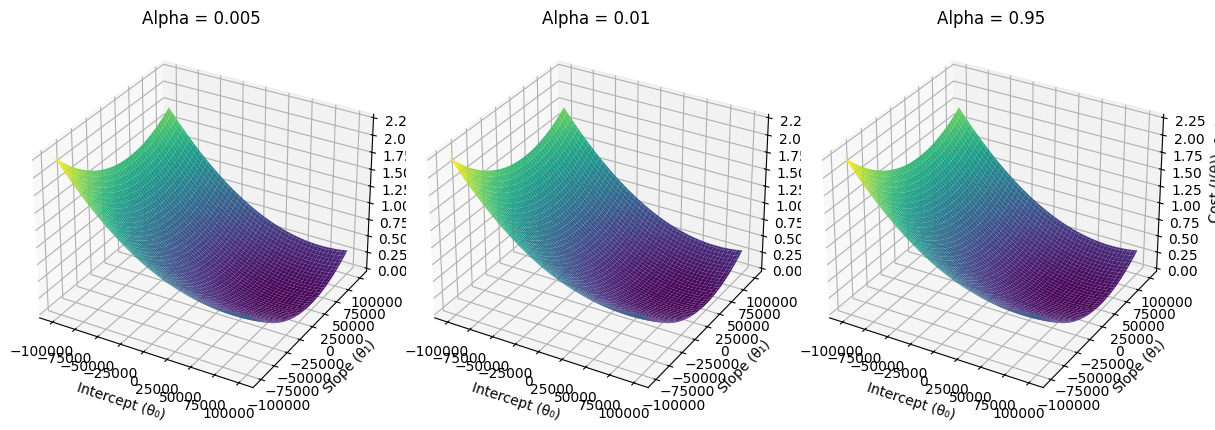

In [ ]:
# 3D Plot: Cost vs Intercept & Slope for each alpha
# ------------------------------
# Create a meshgrid for theta_0 (intercept) and theta_1 (slope)
theta_0_vals = np.linspace(-100000, 100000, 100)
theta_1_vals = np.linspace(-100000, 100000, 100)

# Create grid of intercept and slope values
theta_0_grid, theta_1_grid = np.meshgrid(theta_0_vals, theta_1_vals)

# Compute the cost for each combination of intercept and slope
cost_vals = np.zeros_like(theta_0_grid)
for i in range(len(theta_0_vals)):
    for j in range(len(theta_1_vals)):
        theta_temp = np.array([theta_0_grid[i, j], theta_1_grid[i, j]])
        predictions = X_train_design.dot(theta_temp)
        errors = predictions - y_train
        cost_vals[i, j] = (1/(2 * len(y_train))) * np.sum(errors**2)

# Plotting the 3D surface plot for each alpha value
fig = plt.figure(figsize=(12, 9))

for idx, alpha in enumerate(alpha_values):
    ax = fig.add_subplot(1, len(alpha_values), idx + 1, projection='3d')
    ax.plot_surface(theta_0_grid, theta_1_grid, cost_vals, cmap='viridis')
    ax.set_xlabel('Intercept (θ₀)')
    ax.set_ylabel('Slope (θ₁)')
    ax.set_zlabel('Cost (J(θ))')
    ax.set_title(f'Alpha = {alpha}')

plt.tight_layout()
plt.show()
